# Total bioenergy demand and the sectoral breakdown
Input:
- Feedstock consumption for sectoral bioenergy demand in BioEnerHigh, BioEnerLow, and LimFor

Aims:
- For policy makers to understand where energy consumption comes from; actions needed to take pressures off biomass supply (i.e. going from BioEnerHigh to BioEnerLow)
- For NGOs to push narratives on decarbonising energy system and on implementing measures that promote energy efficiency. To meet energy demand through biomass supply, it would need:
  - Increase in forestry biomass, incl. harvestable wood
  - Increase in energy crops
  - Finding alternative energy source such as natural gas

Output:
- Stacked line plot showing bioenergy demand from household, transport, industry, power and district heat, and tertiary sectors
- Covering 2015 - 2050
- Three scenarios

In [47]:
# Data modification
import pandas as pd
import numpy as np
import pyam

# System
from pathlib import Path

# Plotting
import matplotlib.pyplot as plt

# Output directory

In [48]:
out_dir = Path.cwd() / ".." / "02-output_data"

In [49]:
out_fig_dir = Path.cwd() / ".." / "03-output_figures"

# Scenario data

In [50]:
# Scenario data is a processed dataset, it is stored in output_data directory
master_df = pyam.IamDataFrame(pd.read_csv(f"{out_dir}/master_scenarios_biofuels.csv"))

# Aggregating bioenergy demand per sector

In [51]:
sector = [
    "Household Demand", "Transport Demand", 
    "Industry Demand", "Electricity and District heat Demand", 
    "Tertiary and other Demand"
]

pyam_template = []

for s in sector:
    master_subset = master_df.filter(variable=f"{s}|All Biofuels*")

    # Aggregating biomass supply for sectoral demands
    master_subset_agg = master_subset.aggregate(f"{s}|All Biofuels")

    # Clean variable name
    master_subset_agg.rename(
        variable={f"{s}|All Biofuels" : s}, inplace=True
    )

    pyam_template.append(master_subset_agg)

sectoral_demand = pyam.concat(pyam_template)

In [52]:
sectoral_demand.variable

['Electricity and District heat Demand',
 'Household Demand',
 'Industry Demand',
 'Tertiary and other Demand',
 'Transport Demand']

In [53]:
# Control dataset
sectoral_demand.filter(variable="Household Demand*").timeseries()

2015  \
model     scenario    region variable         unit                 
D5.1 Data BioEnerHigh EU27   Household Demand EJ        1.922047   
                                              ktoe  45907.311681   
          BioEnerLow  EU27   Household Demand EJ        1.921703   
                                              ktoe  45899.083551   
          LimFor      EU27   Household Demand EJ        1.921703   
                                              ktoe  45899.083551   

                                                            2020  \
model     scenario    region variable         unit                 
D5.1 Data BioEnerHigh EU27   Household Demand EJ        1.961893   
                                              ktoe  46858.999026   
          BioEnerLow  EU27   Household Demand EJ        1.961887   
                                              ktoe  46858.862247   
          LimFor      EU27   Household Demand EJ        1.961887   
                                              ktoe  46858.862247   

                                                            2025  \
model     scenario    region variable         unit                 
D5.1 Data BioEnerHigh EU27   Household Demand EJ        1.780541   
                                              ktoe  42527.484457   
          BioEnerLow  EU27   Household Demand EJ        1.728630   
                                              ktoe  41287.618007   
          LimFor      EU27   Household Demand EJ        1.738936   
                                              ktoe  41533.780878   

                                                            2030  \
model     scenario    region variable         unit                 
D5.1 Data BioEnerHigh EU27   Household Demand EJ        1.553136   
                                              ktoe  37096.027853   
          BioEnerLow  EU27   Household Demand EJ        1.491878   
                                              ktoe  35632.889309   
          LimFor      EU27   Household Demand EJ        1.488273   
                                              ktoe  35546.778485   

                                                            2035  \
model     scenario    region variable         unit                 
D5.1 Data BioEnerHigh EU27   Household Demand EJ        1.420214   
                                              ktoe  33921.220067   
          BioEnerLow  EU27   Household Demand EJ        1.343294   
                                              ktoe  32084.030029   
          LimFor      EU27   Household Demand EJ        1.343073   
                                              ktoe  32078.747855   

                                                            2040  \
model     scenario    region variable         unit                 
D5.1 Data BioEnerHigh EU27   Household Demand EJ        1.354999   
                                              ktoe  32363.594635   
          BioEnerLow  EU27   Household Demand EJ        1.240616   
                                              ktoe  29631.611515   
          LimFor      EU27   Household Demand EJ        1.236960   
                                              ktoe  29544.271254   

                                                            2045          2050  
model     scenario    region variable         unit                              
D5.1 Data BioEnerHigh EU27   Household Demand EJ        1.370888      1.273173  
                                              ktoe  32743.090521  30409.206939  
          BioEnerLow  EU27   Household Demand EJ        1.232161      1.139211  
                                              ktoe  29429.650575  27209.594165  
          LimFor      EU27   Household Demand EJ        1.231947      1.136724  
                                              ktoe  29424.538888  27150.177411

# Plotting the sectoral breakdown of bioenergy demand

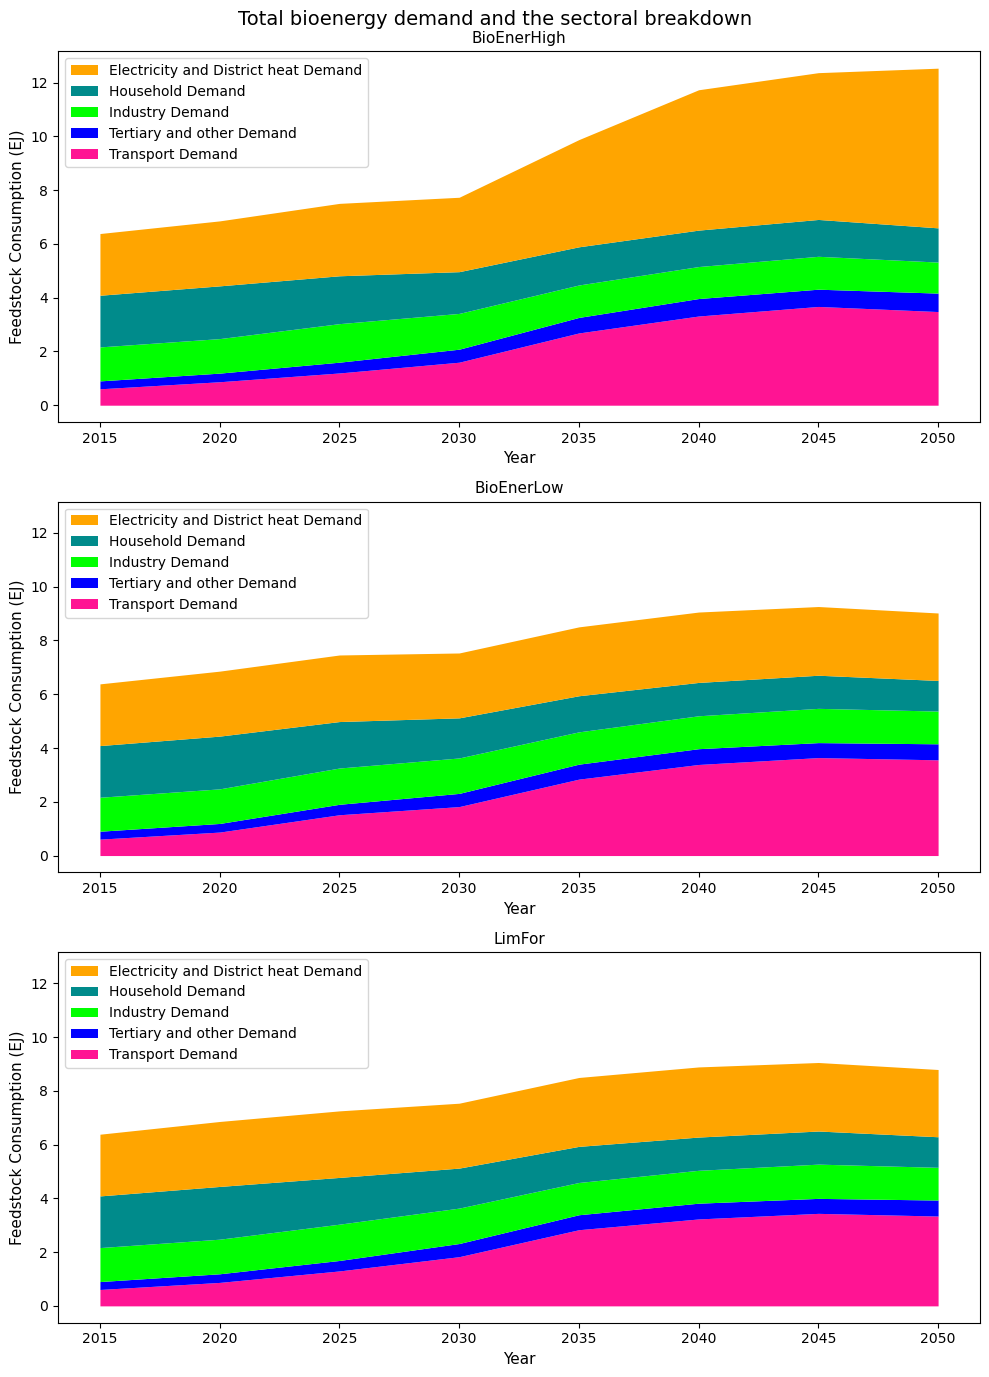

In [84]:
# Configure the color
var_color = {
    "Household Demand" : "#008b8b",
    "Electricity and District heat Demand" : "#ffa500",
    "Industry Demand" : "#00ff00",
    "Tertiary and other Demand" : "#0000ff",
    "Transport Demand" : "#ff1493"
}

pyam.run_control()["color"]["variable"] = var_color

fig, axes = plt.subplots(3, 1, figsize=(10, 14), sharey=True)
plt.suptitle("Total bioenergy demand and the sectoral breakdown", fontsize=14)

for scene, ax in zip(sectoral_demand.scenario, axes.flat):
    data = sectoral_demand.filter(
        scenario=scene,
        unit="EJ"
    )

    data.plot.stack(title=scene, ax=ax, legend=False)

    # Set the fontsize for the axis titles
    ax.set(
        ylabel="Feedstock Consumption (EJ)",
        xlabel="Year"
    )

    # Set the fontsize of the axis titles
    ax.yaxis.label.set_size(11)
    ax.xaxis.label.set_size(11)
    ax.title.set_size(11)

    ax.legend(loc="upper left")

plt.tight_layout()
plt.savefig(f"{out_fig_dir}/stacked_line_sectoral_demand.png", dpi=300)

# Regional distribution of sectoral demand